In [198]:
import numpy as np 
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import statsmodels.tsa.stattools as sm
%matplotlib inline

# In sample 

In [199]:
START = "2014-01-01" # May need to tweak based on when stock introduced - some are quite old!!
END = "2025-01-01" # End of training data, and start of OOS
PRICE = "Close" # Can do High, Low, Open, etc. - Close is normally same as Open for subsequent day, with some drift 
TRANSACTION_PRICE = 0.05 # Flat fee per transaction -  could adjust per size of trade...? 
THRESHOLD = 2 # The z-score threshold, which will pretty dramatically affect Sharpe ratio - tuning too finely for in-sample normally cooks OOS
# Min and max for threshold sweep (in z-scores)
T_MIN = 0.05
T_MAX = 3.5
T_STEP = 0.01

A_stock = "V" # Formerly needed to have larger stock value as B, but solved
B_stock = "MA" 

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


2768 2768


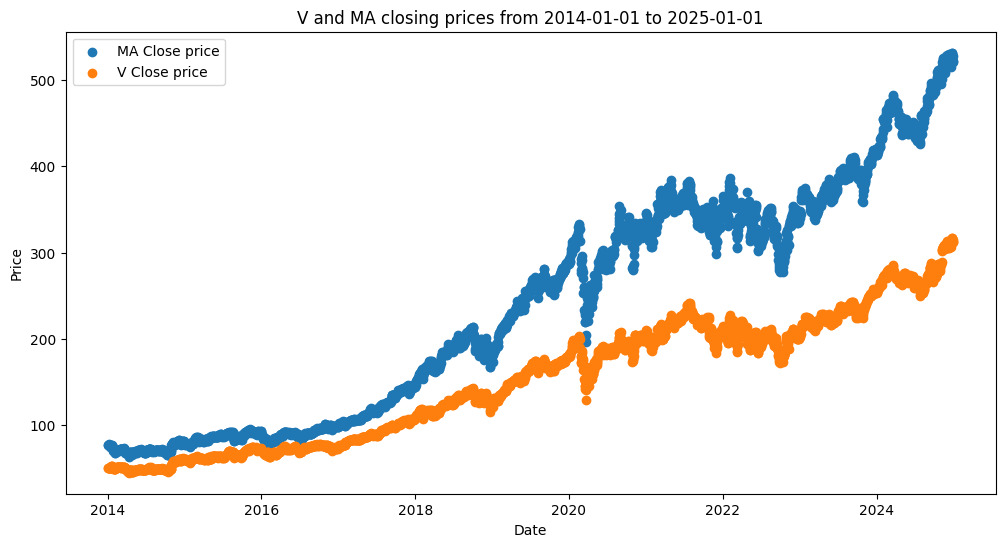

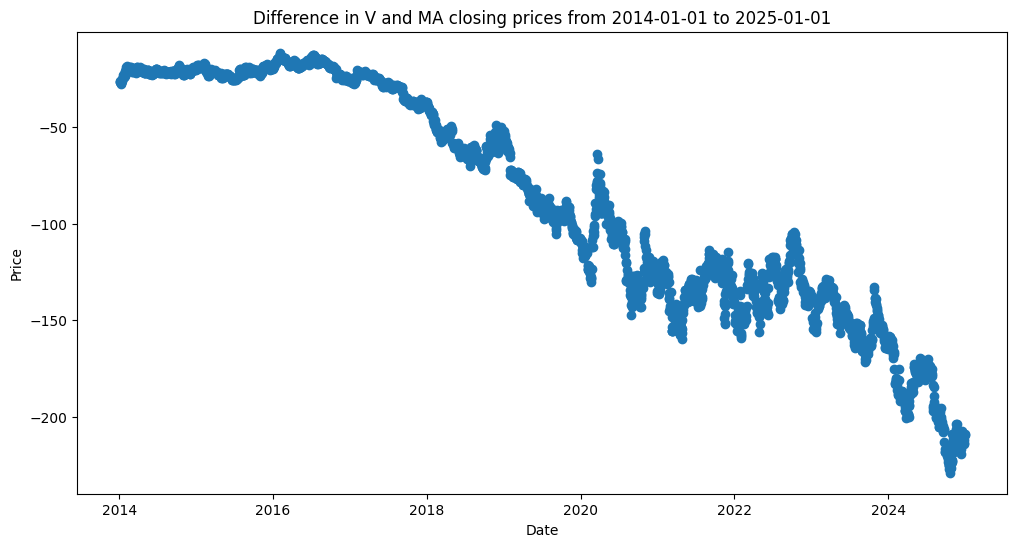

In [200]:
B_data = yf.download(B_stock, start=START, end=END);
A_data = yf.download(A_stock, start=START, end=END);


# Logic for swapping stocks as needed to keep signs in check 
if A_data[PRICE].values.flatten().mean() > B_data[PRICE].values.flatten().mean():
    temp = A_data
    A_data = B_data
    B_data = temp

# Making sure there is data for the entire length of time
print(len(B_data.index), len(A_data.index))

time_data = B_data.index

A_values = A_data[PRICE].values.flatten()
B_values = B_data[PRICE].values.flatten()



plt.figure(figsize=(12, 6))
plt.scatter(time_data, B_data[PRICE], label=f"{B_stock} {PRICE} price")
plt.scatter(time_data, A_data[PRICE], label=f"{A_stock} {PRICE} price")
plt.title(f"{A_stock} and {B_stock} closing prices from {START} to {END}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(time_data, (A_values - B_values), label="Difference")
plt.title(f"Difference in {A_stock} and {B_stock} closing prices from {START} to {END}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Coint tests (in-sample)

In [201]:
# Checking the cointegration value - lower p-value is better (Null is no cointegration)
_, p_value, _ = sm.coint(B_values, A_values)
print(f"Cointegration p-value: {p_value:.4f}")

Cointegration p-value: 0.0006


## Trading (in-sample)

In [202]:
# Linear regression on stocks, params[0] is the linear term, params[1] is the constant term  
params = np.polyfit(B_values, A_values, deg=1)
print(params)

[ 0.55127903 20.19574504]


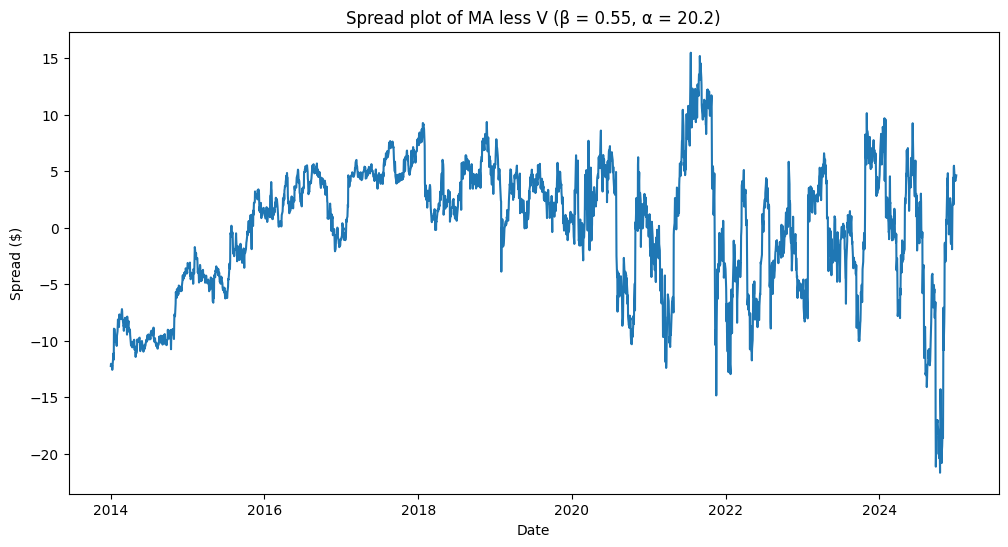

In [203]:
# The spread has the form A - β*B - α - β determines the relative weight of holdings needed for balance 
spread = A_values - params[0]*B_values - params[1]

plt.figure(figsize=(12, 6))
plt.plot(time_data, spread, label="Spread")
plt.title(f"Spread plot of {B_stock} less {A_stock} (\u03B2 = {round(params[0], 2)}, \u03b1 = {round(params[1], 2)})")
plt.xlabel("Date")
plt.ylabel("Spread ($)")
plt.plot();

Spread mean = -1.69e-14, spread std = 5.76


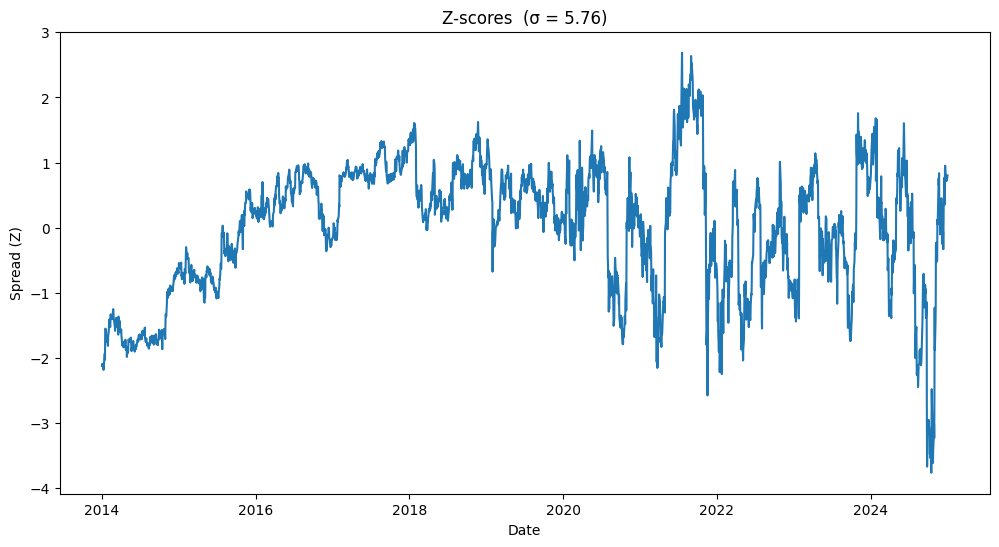

In [204]:
print(f"Spread mean = {np.mean(spread):.2e}, spread std = {np.std(spread):.2f}") # Hoping for mean close to 0, standard deviation gives scaling to extract z-value 

sigma = np.std(spread)

z_scores = spread / sigma

plt.figure(figsize=(12, 6))
plt.plot(time_data, z_scores, label="Spread")
plt.title(f"Z-scores  (\u03C3 = {round(sigma, 2)})")
plt.xlabel("Date")
plt.ylabel("Spread (Z)")
plt.plot();

In [205]:
# Simple logic for signal-generation - could be scalar, but the sharp threshold is a good baseline. Negative for short (sell because expect spread to close) and vice versa for long
def signal(z, threshold):
    if z > threshold: return -1 # Short the spread
    elif z < -threshold: return 1 # Long the spread
    return 0 # Flat

signals = list(map(lambda z: signal(z, threshold=THRESHOLD), z_scores))

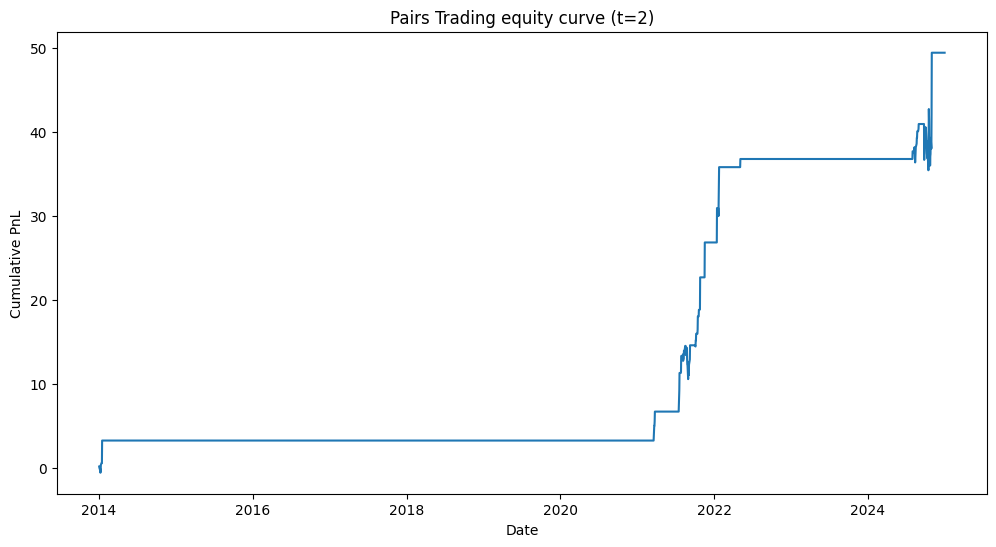

In [206]:
# First term gives PnL per transaction (lossy if signal is negative - short by selling - vice versa if long)
# Second term is transaction cost - constant per transaction, regardless of direction and size 
PnL = signals[:-1] * np.diff(spread) - (np.abs(signals[:-1])*TRANSACTION_PRICE);

plt.figure(figsize=(12, 6))
plt.plot(time_data[:-1], np.cumsum(PnL))
plt.title(f"Pairs Trading equity curve (t={THRESHOLD})")
plt.ylabel("Cumulative PnL")
plt.xlabel("Date")
plt.plot();

In [207]:
print(f"In-sample Sharpe ratio is {np.mean(PnL) / np.std(PnL) * np.sqrt(252):.2f}") # Normalized per day

In-sample Sharpe ratio is 0.86


The max Sharpe ratio in-sample is achieved with a threshold = 1.23


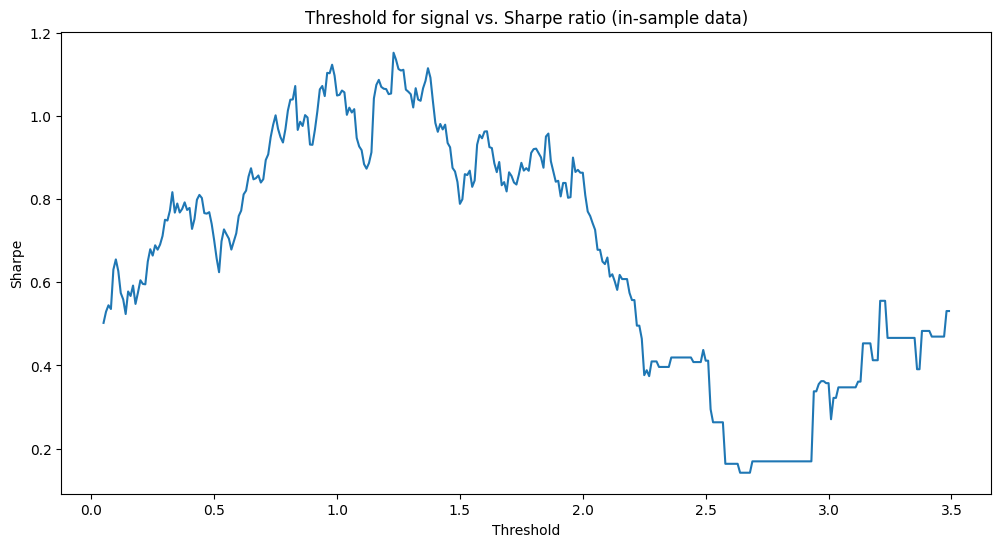

In [208]:
# Threshold sweep logic. Pops out the Sharpe ratio per threshold, and the optimal threshold 
ts = np.arange(T_MIN, T_MAX, T_STEP)
sharpes = []

for t in ts:
    signals = list(map(lambda e: signal(e, threshold=t), z_scores))
    PnL = signals[:-1] * np.diff(spread) - (np.abs(signals[:-1])*TRANSACTION_PRICE)
    sharpes.append(np.mean(PnL) / np.std(PnL) * np.sqrt(252))



plt.figure(figsize=(12, 6))
plt.plot(ts, sharpes)
plt.title(f"Threshold for signal vs. Sharpe ratio (in-sample data)")
plt.ylabel("Sharpe")
plt.xlabel("Threshold")
plt.plot();

in_sample_t_opt = ts[np.argmax(sharpes)]
print(f"The max Sharpe ratio in-sample is achieved with a threshold = {in_sample_t_opt:.2f}")

# Out-of-sample (all logic exactly the same)

In [209]:
B_test_data = yf.download(B_stock, start=END, end=None)
A_test_data = yf.download(A_stock, start=END, end=None)

if A_test_data[PRICE].values.flatten().mean() > B_test_data[PRICE].values.flatten().mean():
    temp = A_test_data
    A_test_data = B_test_data
    B_test_data = temp

_, p_value, _ = sm.coint(B_test_data[PRICE].values.flatten(), A_test_data[PRICE].values.flatten())
print(f"Cointegration p-value: {p_value:.2e}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Cointegration p-value: 6.25e-01


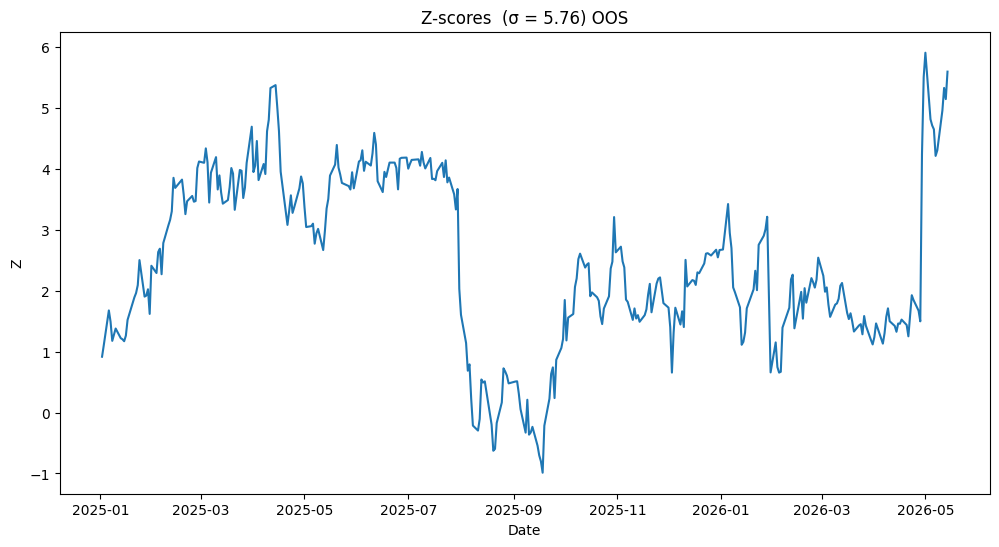

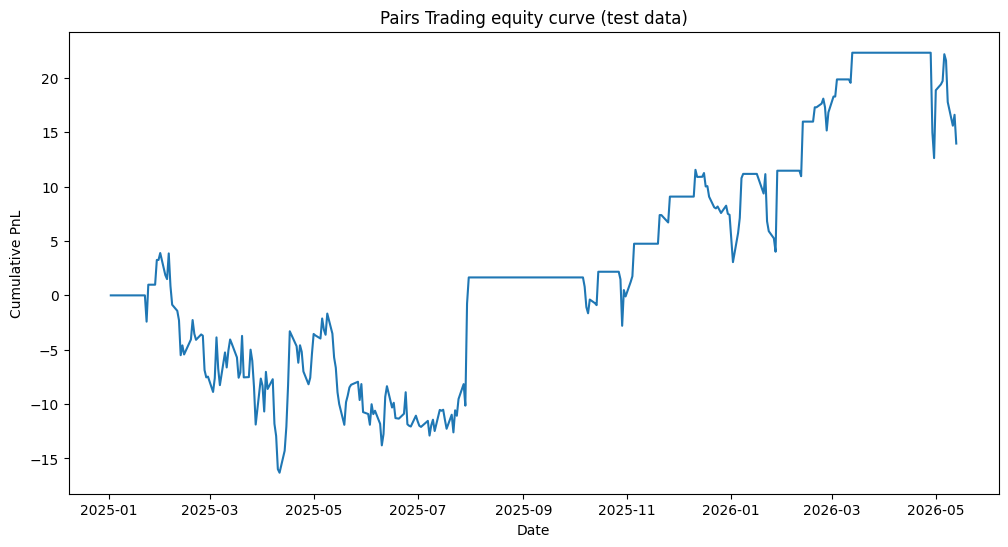

In [210]:
test_time_data = A_test_data.index

# Not re-regressing, obviously. The parameters used are exactly the same as before, and we have to hope the behaviour matches
test_spread = A_test_data[PRICE].values.flatten() - params[0] * B_test_data[PRICE].values.flatten() - params[1]

test_z_scores = test_spread / sigma # Same sigma as from in sample - part of why strategy degrades

test_signals = list(map(lambda e: signal(e, threshold=THRESHOLD), test_z_scores)) # Same signal function

test_PnL = test_signals[:-1] * np.diff(test_spread) - (np.abs(test_signals[:-1])*TRANSACTION_PRICE)

plt.figure(figsize=(12, 6))
plt.plot(test_time_data, test_z_scores, label="Spread")
plt.title(f"Z-scores  (\u03C3 = {round(sigma, 2)}) OOS")
plt.xlabel("Date")
plt.ylabel("Z")
plt.plot();

plt.figure(figsize=(12, 6))
plt.plot(test_time_data[:-1], np.cumsum(test_PnL))
plt.title(f"Pairs Trading equity curve (test data)")
plt.ylabel("Cumulative PnL")
plt.xlabel("Date")
plt.plot();

In [211]:
print(f"OOS Sharpe ratio is {np.mean(test_PnL) / np.std(test_PnL) * np.sqrt(252):.2f}") # Normalized per day

OOS Sharpe ratio is 0.40


The max Sharpe ratio OOS is achieved with a threshold = 1.72


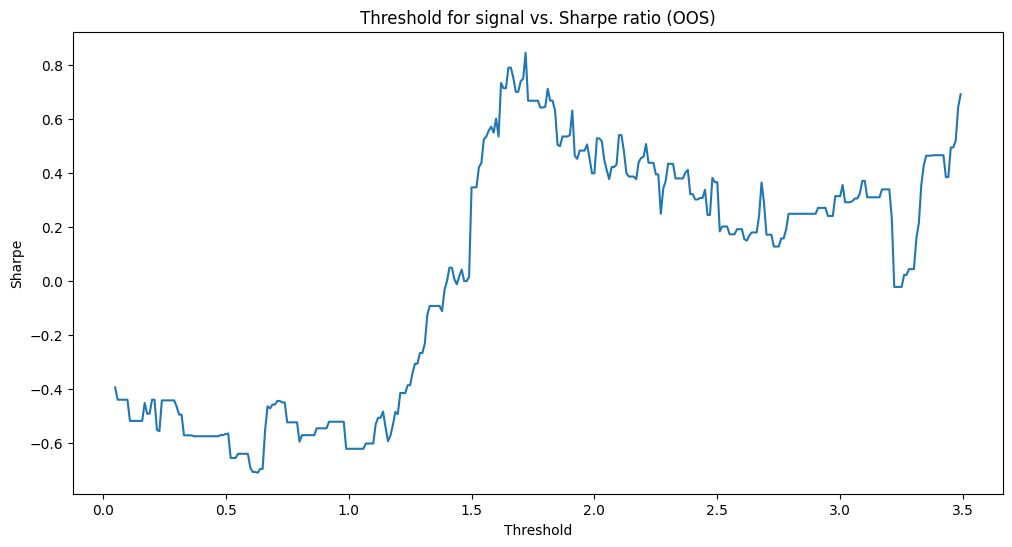

In [212]:
ts = np.arange(T_MIN, T_MAX, T_STEP)
sharpes = []

for t in ts:
    test_signals = list(map(lambda e: signal(e, threshold=t), test_z_scores))
    test_PnL = test_signals[:-1] * np.diff(test_spread) - (np.abs(test_signals[:-1])*TRANSACTION_PRICE)
    sharpes.append(np.mean(test_PnL) / np.std(test_PnL) * np.sqrt(252))



plt.figure(figsize=(12, 6))
plt.plot(ts, sharpes)
plt.title(f"Threshold for signal vs. Sharpe ratio (OOS)")
plt.ylabel("Sharpe")
plt.xlabel("Threshold")
plt.plot()

oos_t_opt = ts[np.argmax(sharpes)]
print(f"The max Sharpe ratio OOS is achieved with a threshold = {oos_t_opt:.2f}")


In [213]:
print(f"In-sample optimal threshold = {in_sample_t_opt:.2f}, OOS optimal threshold = {oos_t_opt:.2f}")

In-sample optimal threshold = 1.23, OOS optimal threshold = 1.72


# All time

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


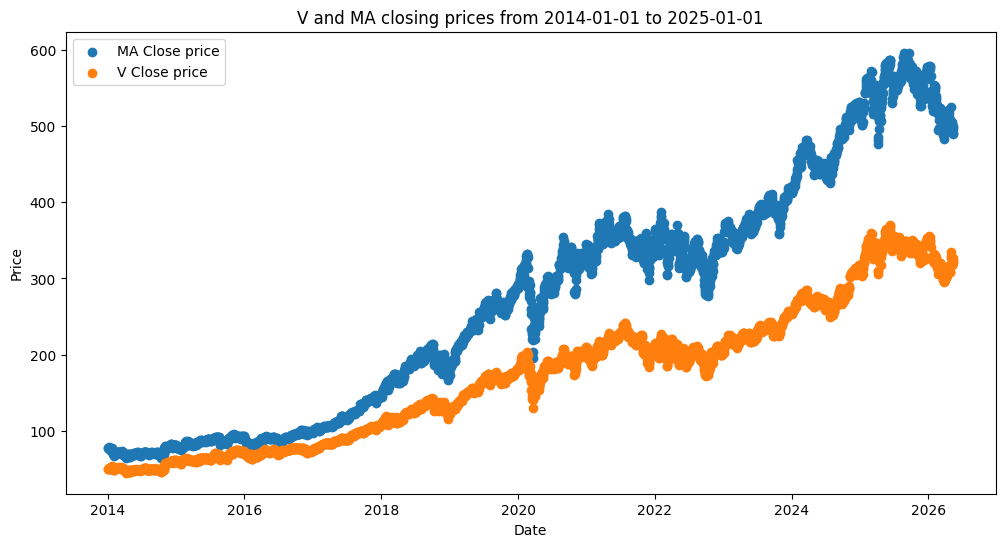

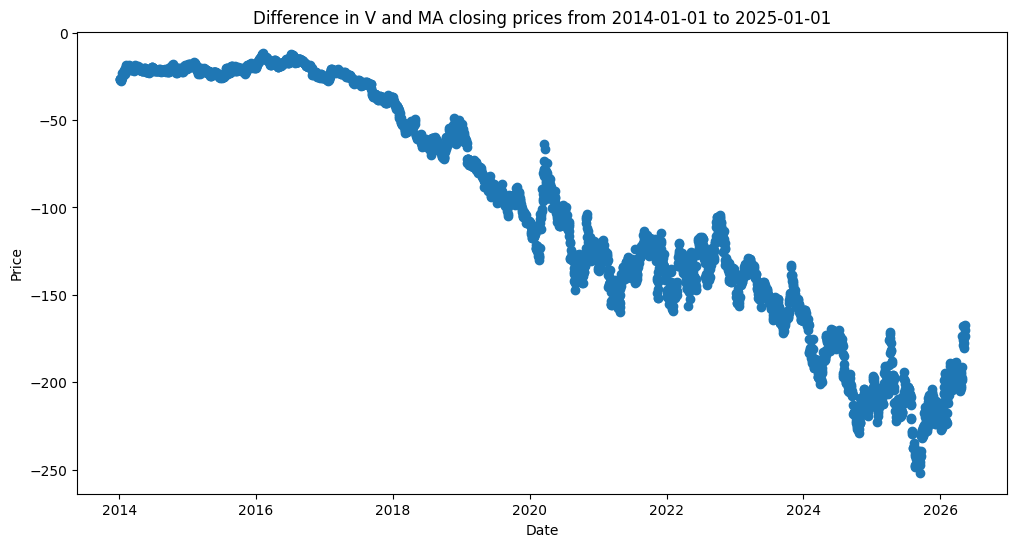

In [214]:
B_data = yf.download(B_stock, start=START, end=None)
A_data = yf.download(A_stock, start=START, end=None)

time_data = B_data.index

plt.figure(figsize=(12, 6))
plt.scatter(time_data, B_data[PRICE], label=f"{B_stock} {PRICE} price")
plt.scatter(time_data, A_data[PRICE], label=f"{A_stock} {PRICE} price")
plt.title(f"{A_stock} and {B_stock} closing prices from {START} to {END}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show();

plt.figure(figsize=(12, 6))
plt.scatter(time_data, (A_data[PRICE].values.flatten() - B_data[PRICE].values.flatten()), label="Difference")
plt.title(f"Difference in {A_stock} and {B_stock} closing prices from {START} to {END}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show();